# Student-Performance-Analysis

## Objective
Clean and analyze student data using Pandas to extract insights.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "name":["Rahul","Aman","Sara","John",None,"Vikas","Riya"],
    "marks":[78, None, 85, 60, 70, 88, 95],
    "city":["Bhopal", "Indore", None, "Delhi", "Indore", "Delhi", "Bhopal"],
    "age":[21, 22, None, 23, 22, None, 21]
}
df = pd.DataFrame(data)
print(df)

    name  marks    city   age
0  Rahul   78.0  Bhopal  21.0
1   Aman    NaN  Indore  22.0
2   Sara   85.0    None   NaN
3   John   60.0   Delhi  23.0
4   None   70.0  Indore  22.0
5  Vikas   88.0   Delhi   NaN
6   Riya   95.0  Bhopal  21.0


## Data Cleaning
Handling missing values in a dataset

In [2]:
#Check missing values
df.isnull().sum()

name     1
marks    1
city     1
age      2
dtype: int64

In [9]:
# fill missing marks with mean
df["marks"] = df["marks"].fillna(df["marks"].mean())
df["marks"] = df["marks"].round(2)
    
# fill missing city with 'unknown'
df["city"] = df["city"].fillna("unknown")
df

,name,marks,city,age
0,Rahul,78.00,Bhopal,21.0
1,Aman,79.33,Indore,22.0
2,Sara,85.00,unknown,NaN
3,John,60.00,Delhi,23.0
5,Vikas,88.00,Delhi,NaN
6,Riya,95.00,Bhopal,21.0


In [8]:
# remove rows where name is missing
df = df.dropna(subset=["name"])
df

,name,marks,city,age
0,Rahul,78.00,Bhopal,21.0
1,Aman,79.33,Indore,22.0
2,Sara,85.00,unknown,NaN
3,John,60.00,Delhi,23.0
5,Vikas,88.00,Delhi,NaN
6,Riya,95.00,Bhopal,21.0


## Feature Engineering
Creating grade column based on marks

In [16]:
def grade(x):
    if x>=85:
        return "A"
    elif x >= 70:
        return "B"
    else:
        return"C"
df["grade"] = df["marks"].apply(grade)

df

,name,marks,city,age,grade
0,Rahul,78.0,Bhopal,21.0,B
1,Aman,NaN,Indore,22.0,C
2,Sara,85.0,None,NaN,A
3,John,60.0,Delhi,23.0,C
4,None,70.0,Indore,22.0,B
5,Vikas,88.0,Delhi,NaN,A
6,Riya,95.0,Bhopal,21.0,A


## Data Analysis
Extracting insights from cleaned data

In [12]:
#average marks
df["marks"].mean().round(2)

np.float64(80.89)

In [13]:
#Students per city
df["city"].value_counts()

city
Bhopal     2
Delhi      2
Indore     1
unknown    1
Name: count, dtype: int64

In [16]:
#Average marks per city
df.groupby("city")["marks"].mean()

city
Bhopal     86.50
Delhi      74.00
Indore     79.33
unknown    85.00
Name: marks, dtype: float64

In [17]:
#Top Students
df[df["grade"] == "A"]

,name,marks,city,age,grade
2,Sara,85.0,unknown,NaN,A
5,Vikas,88.0,Delhi,NaN,A
6,Riya,95.0,Bhopal,21.0,A


In [18]:
#Highest marks student
df.loc[df["marks"].idxmax()]

name       Riya
marks      95.0
city     Bhopal
age        21.0
grade         A
Name: 6, dtype: object

In [19]:
df.to_csv("../data/students.csv", index=False)

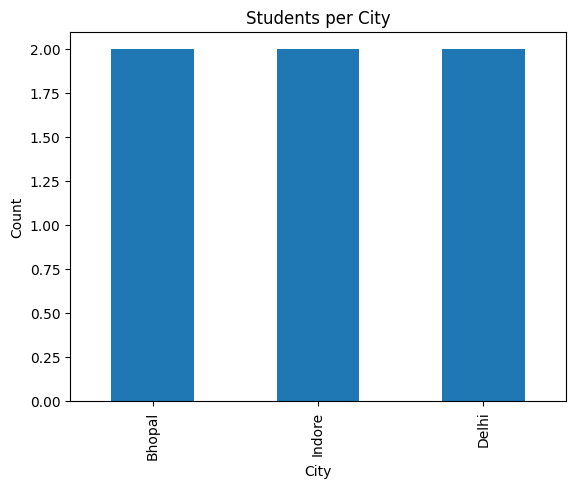

In [5]:
df["city"].value_counts().plot(kind="bar")

plt.title("Students per City")
plt.xlabel("City")
plt.ylabel("Count")

plt.show()

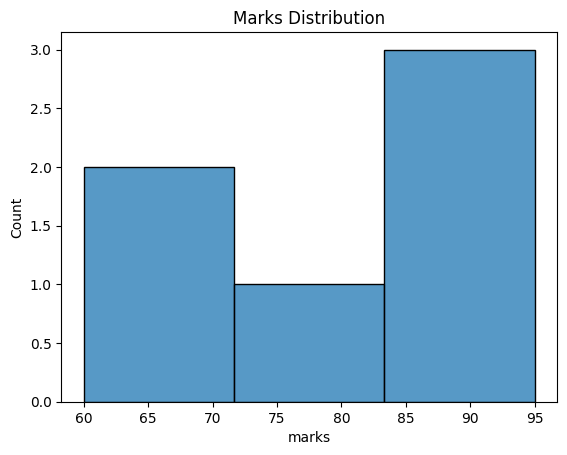

In [12]:
sns.histplot(df["marks"], bins = 3)

plt.title("Marks Distribution")

plt.show()

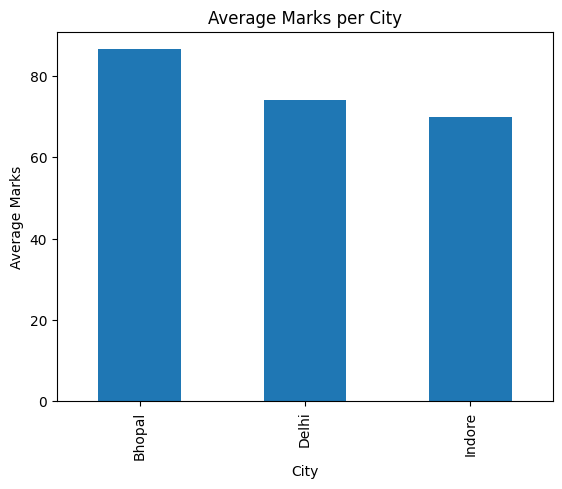

In [13]:
df.groupby("city")["marks"].mean().plot(kind = "bar")

plt.title("Average Marks per City")
plt.xlabel("City")
plt.ylabel("Average Marks")

plt.show()

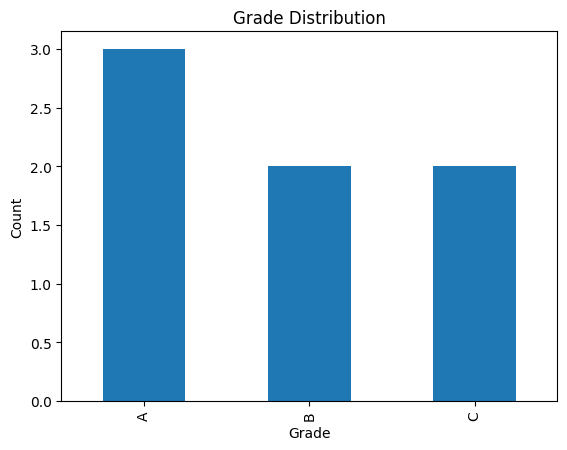

In [17]:
df["grade"].value_counts().plot(kind="bar")

plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")

plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["city_encoded"] = le.fit_transform(df["city"])
df

,name,marks,city,age,grade,city_encoded
0,Rahul,78.0,Bhopal,21.0,B,0
1,Aman,NaN,Indore,22.0,C,2
2,Sara,85.0,None,NaN,A,3
3,John,60.0,Delhi,23.0,C,1
4,None,70.0,Indore,22.0,B,2
5,Vikas,88.0,Delhi,NaN,A,1
6,Riya,95.0,Bhopal,21.0,A,0


In [26]:
df["marks"] = df["marks"].fillna(df["marks"].mean())
df["age"] = df["age"].fillna(df["age"].mean())
X = df[["age","city_encoded"]]
y = df["marks"]
X
y

0    78.000000
1    79.333333
2    85.000000
3    60.000000
4    70.000000
5    88.000000
6    95.000000
Name: marks, dtype: float64

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
model.predict([[21,0]]).round(2)
# If:
# age = 21  
# city = Bhopal (0)

# Then:
# what marks?


C:\Users\Abizar\anaconda3\envs\aiml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([88.13])